# Did a configuration parameter change part way through a raw file?

`HB1603_L1-D20160628-T104140.raw` is the last of 151 HB1603 files, 27 and 28
June 2016, whose 18, 120 and 200 kHz channels matched no calibration file. The
calibration matcher reads **one configuration per file**, taken from the first
ping cycle, so a setting that changes later in a file is invisible to it. This
notebook asks whether that happened here.

It uses echopype to open the raw file and xarray to test every per-ping
transmit parameter for variation along `ping_time`.

In [1]:
# imports
import numpy as np
import xarray as xr
import echopype as ep
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlopen

## User defined variables

The raw files come from the NOAA NCEI Water Column Sonar Data archive, which
serves the HB1603 EK60 files over public HTTPS. They are downloaded once into
`raw_files/` and reused on later runs.

`SUSPECT_FILE` is the file under investigation. `CONTRAST_FILE` is the one that
follows it, included to show what an ordinary file looks like under the same
test.

In [2]:
# User defined variables
NCEI_BASE = "https://noaa-wcsd-pds.s3.amazonaws.com/data/raw/Henry_B._Bigelow/HB1603/EK60"
SUSPECT_FILE = "HB1603_L1-D20160628-T104140.raw"
CONTRAST_FILE = "HB1603_L1-D20160628-T104843.raw"
raw_folder = Path("./raw_files")

# Per-ping parameters echopype exposes on (channel, ping_time).
PING_PARAMS = [
    "transmit_duration_nominal",
    "transmit_power",
    "transmit_bandwidth",
    "sample_interval",
]

raw_folder.mkdir(parents=True, exist_ok=True)

In [3]:
def fetch_raw(filename, folder=raw_folder, base=NCEI_BASE):
    """Download a raw file from the NCEI archive unless it is already local.

    Args:
        filename: Bare ``.raw`` filename.
        folder: Directory to cache the file in.
        base: Archive URL the file hangs off.

    Returns:
        Path: The local file.
    """
    target = folder / filename
    if target.exists():
        print(f"{filename} already downloaded ({target.stat().st_size / 1e6:.1f} MB)")
        return target
    print(f"downloading {filename} ...")
    with urlopen(f"{base}/{filename}") as response:
        target.write_bytes(response.read())
    print(f"  saved {target.stat().st_size / 1e6:.1f} MB to {target}")
    return target


suspect_path = fetch_raw(SUSPECT_FILE)

HB1603_L1-D20160628-T104140.raw already downloaded (44.8 MB)


## Open the file with echopype

`open_raw` returns an `EchoData` object. The transmit settings live in
`Sonar/Beam_group1`, where each is a `(channel, ping_time)` array rather than a
single value per file. That shape is the whole point: it is what lets us ask
whether a parameter held still.

In [4]:
echodata = ep.open_raw(suspect_path, sonar_model="EK60")
beam = echodata["Sonar/Beam_group1"]

print(f"file: {SUSPECT_FILE}")
print(f"dims: {dict(beam.sizes)}")
print()
for name in PING_PARAMS:
    print(f"  {name:<28} dims={beam[name].dims}")

file: HB1603_L1-D20160628-T104140.raw
dims: {'channel': 5, 'ping_time': 416, 'range_sample': 10463, 'beam_group': 1}

  transmit_duration_nominal    dims=('channel', 'ping_time')
  transmit_power               dims=('channel', 'ping_time')
  transmit_bandwidth           dims=('channel', 'ping_time')
  sample_interval              dims=('channel', 'ping_time')


In [5]:
# Label channels by nominal frequency, which reads better than the full channel id.
freq_khz = (beam["frequency_nominal"] / 1000).astype(int)
channel_label = xr.DataArray(
    [f"{int(f)} kHz" for f in freq_khz.values],
    dims="channel",
    coords={"channel": beam.channel},
)

for channel_id, label in zip(beam.channel.values, channel_label.values):
    print(f"  {label:>8}   {channel_id}")

    18 kHz   GPT  18 kHz 009072056b0e 2-1 ES18-11
    38 kHz   GPT  38 kHz 0090720346bc 1-1 ES38B
    70 kHz   GPT  70 kHz 00907206042f 5-1 ES70-7C
   120 kHz   GPT 120 kHz 0090720580f1 3-1 ES120-7
   200 kHz   GPT 200 kHz 009072034261 4-1 ES200-7


## Does any parameter vary along ping_time?

For each parameter, compare every ping against that channel's first ping. If
anything differs, the setting did not hold for the whole file.

In [6]:
def varying_channels(dataset, name, labels=None):
    """Channels whose parameter is not constant along ping_time.

    Args:
        dataset: Beam group holding the parameter.
        name: Parameter variable name.
        labels: Per-channel display labels. Defaults to channel_label.

    Returns:
        list[str]: Labels of the channels that vary.
    """
    labels = channel_label if labels is None else labels
    values = dataset[name]
    differs = (values != values.isel(ping_time=0)).any("ping_time")
    return [str(l) for l, d in zip(labels.values, differs.values) if d]


for name in PING_PARAMS:
    varies = varying_channels(beam, name)
    print(f"{name:<28} {'varies on ' + ', '.join(varies) if varies else 'constant'}")

transmit_duration_nominal    varies on 18 kHz, 120 kHz, 200 kHz
transmit_power               constant
transmit_bandwidth           varies on 18 kHz, 120 kHz, 200 kHz
sample_interval              varies on 18 kHz, 120 kHz, 200 kHz


Three of the five channels change, and `transmit_power` is not one of the
parameters involved. That matters: the power difference HB1603 is known for
(leg 1 transmitting 18 and 38 kHz at 2000 W against a 1000 W calibration) is
steady through this file. Whatever changed here is something else.

## Where exactly does it change?

`diff` along `ping_time` is non-zero only at the ping where a value moves.

In [7]:
def change_points(dataset, name, labels=None):
    """Locate every ping at which a parameter changes value.

    Args:
        dataset: Beam group holding the parameter.
        name: Parameter variable name.
        labels: Per-channel display labels. Defaults to channel_label.

    Returns:
        list[dict]: One entry per change, with channel, ping index, time and
        the values either side.
    """
    labels = channel_label if labels is None else labels
    values = dataset[name]
    steps = values.diff("ping_time")
    found = []
    for channel_index, ping_index in np.argwhere(steps.values != 0):
        found.append({
            "channel": str(labels.values[channel_index]),
            "parameter": name,
            # diff position i compares ping i and i+1, and pings are 1-based here.
            "last_ping_before": int(ping_index) + 1,
            "first_ping_after": int(ping_index) + 2,
            "time": dataset.ping_time.values[ping_index + 1],
            "before": float(values.values[channel_index, ping_index]),
            "after": float(values.values[channel_index, ping_index + 1]),
        })
    return found


changes = [c for name in PING_PARAMS for c in change_points(beam, name)]

for c in changes:
    print(f"{c['channel']:>8}  {c['parameter']:<26} ping {c['last_ping_before']} -> "
          f"{c['first_ping_after']}  at {str(c['time'])[:19]}  "
          f"{c['before']:g} -> {c['after']:g}")

  18 kHz  transmit_duration_nominal  ping 396 -> 397  at 2016-06-28T10:48:17  0.002048 -> 0.001024
 120 kHz  transmit_duration_nominal  ping 396 -> 397  at 2016-06-28T10:48:17  0.000256 -> 0.001024
 200 kHz  transmit_duration_nominal  ping 396 -> 397  at 2016-06-28T10:48:17  0.000256 -> 0.001024
  18 kHz  transmit_bandwidth         ping 396 -> 397  at 2016-06-28T10:48:17  1185.94 -> 1573.67
 120 kHz  transmit_bandwidth         ping 396 -> 397  at 2016-06-28T10:48:17  8709.93 -> 3026.39
 200 kHz  transmit_bandwidth         ping 396 -> 397  at 2016-06-28T10:48:17  10635 -> 3088.4
  18 kHz  sample_interval            ping 396 -> 397  at 2016-06-28T10:48:17  0.000512 -> 0.000256
 120 kHz  sample_interval            ping 396 -> 397  at 2016-06-28T10:48:17  6.4e-05 -> 0.000256
 200 kHz  sample_interval            ping 396 -> 397  at 2016-06-28T10:48:17  6.4e-05 -> 0.000256


Every change lands on the same ping and the same instant: **ping 397, at
2016-06-28T10:48:17**. Pulse length, bandwidth and sample interval move
together, which is what a single operator change to pulse length looks like in
an EK60 file. The 18 kHz channel halves its pulse from 2.048 ms to 1.024 ms and
the 120 and 200 kHz channels lengthen theirs from 0.256 ms to 1.024 ms.

All five HB1603 calibrations were measured at 1.024 ms, so the last 20 pings of
this file are at the calibrated pulse length and the first 396 are not.

## The file as segments

Collapsing the pings into runs of identical settings gives the form a
configuration report wants: what was in use, over which pings, between which
times.

In [8]:
def segment_table(dataset, params=None, labels=None):
    """Collapse pings into runs of identical settings, per channel.

    Args:
        dataset: Beam group to summarize.
        params: Parameters that define a distinct configuration.
        labels: Per-channel display labels.

    Returns:
        list[dict]: One entry per run of constant settings.
    """
    params = PING_PARAMS if params is None else params
    labels = channel_label if labels is None else labels
    ping_time = dataset.ping_time.values
    rows = []
    for channel_index, label in enumerate(labels.values):
        values = np.stack([dataset[name].values[channel_index] for name in params])
        # A new segment starts wherever any parameter differs from the ping before.
        changed = np.any(values[:, 1:] != values[:, :-1], axis=0)
        bounds = [0] + list(np.where(changed)[0] + 1) + [values.shape[1]]
        for begin, end in zip(bounds[:-1], bounds[1:]):
            row = {
                "channel": str(label),
                "first_ping": begin + 1,
                "last_ping": end,
                "start_time": ping_time[begin],
                "end_time": ping_time[end - 1],
            }
            row.update({name: values[i, begin] for i, name in enumerate(params)})
            rows.append(row)
    return rows


segments = segment_table(beam)

print(f"{'channel':>8}  {'pings':>11}  {'start':>8}  {'end':>8}  "
      f"{'pulse ms':>9}  {'power W':>8}  {'bw Hz':>9}  {'interval s':>11}")
for row in segments:
    span = f"{row['first_ping']}-{row['last_ping']}"
    print(f"{row['channel']:>8}  {span:>11}  "
          f"{str(row['start_time'])[11:19]:>8}  {str(row['end_time'])[11:19]:>8}  "
          f"{row['transmit_duration_nominal'] * 1000:>9.3f}  "
          f"{row['transmit_power']:>8.0f}  {row['transmit_bandwidth']:>9.1f}  "
          f"{row['sample_interval']:>11.6f}")

 channel        pings     start       end   pulse ms   power W      bw Hz   interval s
  18 kHz        1-396  10:41:40  10:48:16      2.048      2000     1185.9     0.000512
  18 kHz      397-416  10:48:17  10:48:38      1.024      2000     1573.7     0.000256
  38 kHz        1-416  10:41:40  10:48:38      1.024      2000     2425.1     0.000256
  70 kHz        1-416  10:41:40  10:48:38      1.024       750     2859.1     0.000256
 120 kHz        1-396  10:41:40  10:48:16      0.256       500     8709.9     0.000064
 120 kHz      397-416  10:48:17  10:48:38      1.024       500     3026.4     0.000256
 200 kHz        1-396  10:41:40  10:48:16      0.256       300    10635.0     0.000064
 200 kHz      397-416  10:48:17  10:48:38      1.024       300     3088.4     0.000256


In [27]:
echodata["Sonar/Beam_group1"]["transmit_duration_nominal"].isel(channel=4, ping_time=slice(390, 410))

<xarray.DataArray 'transmit_duration_nominal' (ping_time: 20)> Size: 160B
array([0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
       0.001024, 0.001024, 0.001024, 0.001024, 0.001024, 0.001024,
       0.001024, 0.001024, 0.001024, 0.001024, 0.001024, 0.001024,
       0.001024, 0.001024])
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 160B 2016-06-28T10:48:11.459293 ......
    channel    <U36 144B 'GPT 200 kHz 009072034261 4-1 ES200-7'
Attributes:
    long_name:  Nominal bandwidth of transmitted pulse
    units:      s
    valid_min:  0.0

## Plot

Pulse length against ping number, with the calibrated 1.024 ms drawn for
reference. The 38 and 70 kHz channels sit on that line the whole way; the other
three step onto it at ping 397. Channels are drawn with distinct line styles
because several of them sit at identical values and would otherwise hide each
other.

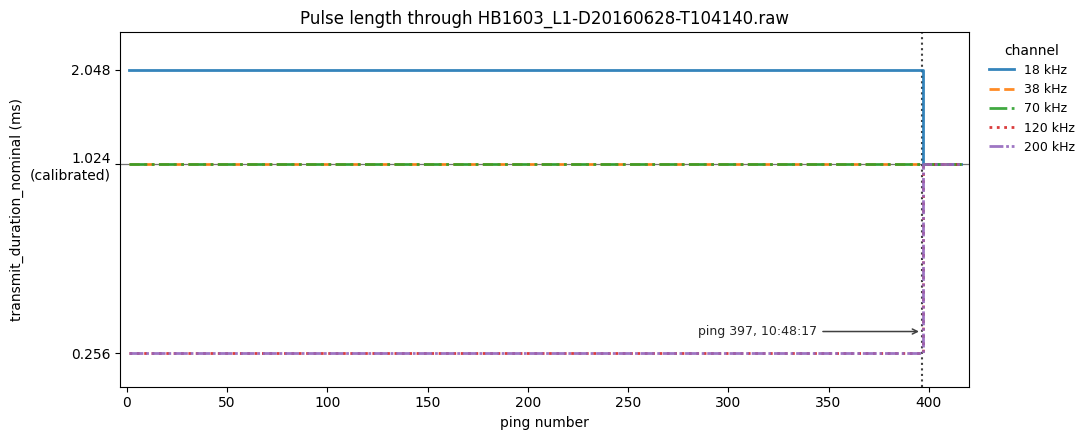

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))

pings = np.arange(1, beam.sizes["ping_time"] + 1)
styles = ["-", "--", "-.", ":", (0, (5, 1, 1, 1))]
for channel_index, label in enumerate(channel_label.values):
    pulse_ms = beam["transmit_duration_nominal"].values[channel_index] * 1000
    ax.step(pings, pulse_ms, where="post", label=str(label),
            linewidth=2.0, linestyle=styles[channel_index], alpha=0.9)

ax.axhline(1.024, color="0.45", linewidth=0.9, zorder=0)
ax.axvline(396.5, color="0.25", linestyle=":", linewidth=1.5, zorder=0)
ax.annotate("ping 397, 10:48:17", xy=(396.5, 0.30), xytext=(285, 0.30),
            color="0.15", fontsize=9, va="center",
            arrowprops=dict(arrowstyle="->", color="0.25", linewidth=1.1))

ax.set_yscale("log")
ax.set_yticks([0.256, 1.024, 2.048])
ax.set_yticklabels(["0.256", "1.024\n(calibrated)", "2.048"])
ax.minorticks_off()
ax.set_ylim(0.2, 2.7)
ax.set_xlabel("ping number")
ax.set_ylabel("transmit_duration_nominal (ms)")
ax.set_title(f"Pulse length through {SUSPECT_FILE}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9,
          frameon=False, title="channel")
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

## A file that does not change, for contrast

Running the same test on the next file shows what a clean result looks like,
and shows one thing worth separating out. The sounder's recorded sound speed
does move, at ping 14. That is an environmental value, not a transmit setting
the operator chose, and it is not one of the fields calibration matching
compares. A configuration report should keep the two apart.

In [11]:
contrast_path = fetch_raw(CONTRAST_FILE)
contrast_data = ep.open_raw(contrast_path, sonar_model="EK60")
contrast = contrast_data["Sonar/Beam_group1"]
contrast_labels = xr.DataArray(
    [f"{int(f)} kHz"
     for f in (contrast["frequency_nominal"] / 1000).astype(int).values],
    dims="channel",
    coords={"channel": contrast.channel},
)

print(f"file: {CONTRAST_FILE}  ({contrast.sizes['ping_time']} pings)")
for name in PING_PARAMS:
    varies = varying_channels(contrast, name, labels=contrast_labels)
    print(f"  {name:<28} {'varies on ' + ', '.join(varies) if varies else 'constant'}")

sound_speed = contrast_data["Environment"]["sound_speed_indicative"]
print()
print(f"sound_speed_indicative: {float(sound_speed.min()):g} to "
      f"{float(sound_speed.max()):g} m/s")

HB1603_L1-D20160628-T104843.raw already downloaded (34.5 MB)
file: HB1603_L1-D20160628-T104843.raw  (279 pings)
  transmit_duration_nominal    constant
  transmit_power               constant
  transmit_bandwidth           constant
  sample_interval              constant

sound_speed_indicative: 1493.3 to 1512.7 m/s


## What this means for the calibration mapping

The answer is yes: a parameter did change part way through
`HB1603_L1-D20160628-T104140.raw`, at ping 397 of 416.

The pipeline could not have seen it. `read_raw_file_config` derives one
configuration per file, and for EK60 it stops reading as soon as every channel
has been seen transmitting once, which is the first ping cycle. So this file
was characterised entirely by its pre-change settings: 18 kHz at 2.048 ms, 120
and 200 kHz at 0.256 ms, none of which match the 1.024 ms the calibrations were
measured at. Those three channels fell back to the values the raw file records
for them, across all 416 pings, including the final 20 that were already at the
calibrated pulse length.

Two practical consequences:

- A configuration report built from per-file configurations cannot state
  mid-file changes. Answering that question needs a pass like this one, over
  the per-ping arrays.
- The parameter that varies is pulse length, not transmit power. Widening the
  `transmit_power` match tolerance does not reach it, and widening
  `transmit_duration_nominal` would not be a tolerance question: pulse length
  sets the effective pulse duration and the equivalent beam correction, so a
  2x or 4x difference is a different measurement.

`segment_table` above is the reusable piece. Run it over a set of files and the
result is a per-channel account of which settings were in use over which time
ranges, at ping resolution rather than file resolution.